In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [163]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sbn
from matplotlib.ticker import ScalarFormatter
from scipy.stats import ks_2samp

In [4]:
races=pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")
placements=pd.read_csv('../dataset/preprocessedPlacements.csv', sep=",")
cyclists=pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")

In [5]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

# Data preparation

## Feature selection

Reconstruction of the original dataset by merging the three dataset produced for the previous tasks. We do not include in the final dataset those columns excluded from the analysis due not resolved data quality issues or because of redundancy. 

In [6]:
cyclists.drop(['AVG weighted position', 'AVG position Autumn', 'AVG position Spring', 'AVG position Summer', 'AVG position Winter', 'AVG position Q1', 'AVG position Q2', 'AVG position Q3', 'AVG position Q4'], axis=1, inplace=True)
cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

In [7]:
races.drop(['uci_points', 'average_temperature', 'is_tarmac', 'is_cobbled', 'is_gravel'], axis=1, inplace=True)
races.columns

Index(['_url', 'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [8]:
placements.drop(['cyclist_team'], axis=1, inplace=True)
placements.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date', '_url', 'year'], dtype='object')

In [9]:
placements.head()

,position,cyclist,cyclist_age,delta,date,_url,year
0,0,georges-pintens,24,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,33,1970-04-25,amstel-gold-race/1970/result,1970


In [10]:
races.head()

,_url,name,points,length,climb_total,profile,startlist_quality,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,162000,1101,1,1241,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,196000,5575,5,821,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,128000,781,1,1699,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,8100,68,1,804,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,192900,3743,3,1551,2022-07-10,0.019404,1376.0,675.354230


In [11]:
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,24.497844
1,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,32.648452
3,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,26.276978


Reconstruction of the original dataset including the new features.

In [12]:
dataset=pd.merge(placements, races, how='inner', on='_url')
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date_x', '_url', 'year',
       'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date_y', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [13]:
dataset.drop(['date_y', 'date_x'], axis=1, inplace=True)

In [14]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta'],
      dtype='object')

In [15]:
dataset=pd.merge(dataset, cyclists, how='inner', left_on='cyclist', right_on='name')

In [16]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name_x',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta', 'name_y', 'BMI',
       'median position', 'AVG position', '# cyclist races', 'nationality',
       'continent', 'geo area', 'birth_year', 'std_dev position'],
      dtype='object')

In [17]:
dataset.drop(['name_x', 'name_y'], axis=1, inplace=True)

In [18]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'median position', 'AVG position',
       '# cyclist races', 'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

Actually we will use our model to predict the future placements (>=2022) of the cylists, for this reason we need to adjust some statistics of the cyclists which are calculated on the whole dataset, hence considering all the placements which are in the range (1970-2023). Moreover we need to exclude those columns that, in some sense, immediately allow us to assing the proper label (such as the _'position'_ but also the _'delta'_).

### Redefinition of the cyclist statistics

In [19]:
new_stats=pd.merge(placements, cyclists, left_on='cyclist', right_on='name', how='inner')

In [20]:
print(f"# of placements: {new_stats.shape[0]}")
print(f"# of placements >=2022: {new_stats[new_stats['year']>=2022].shape[0]}")

# of placements: 589865
# of placements >=2022: 35406


In [21]:
new_stats=new_stats[['cyclist','position', 'year']]
new_stats=new_stats[new_stats['year']<2022]
new_stats

,cyclist,position,year
0,georges-pintens,0,1970
1,willy-van-neste,1,1970
2,andre-dierickx,2,1970
3,eric-leman,3,1970
4,joseph-schoeters,4,1970
...,...,...,...
589757,johan-esteban-chaves,63,2021
589758,nelson-soto,64,2021
589759,pascal-eenkhoorn,65,2021
589760,nikias-arndt,66,2021


In [22]:
print(f"# of cyclists with placements <2022:{new_stats['cyclist'].unique().shape[0]}")

# of cyclists with placements <2022:5786


In [23]:
new_stats['median position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.median()))
new_stats['AVG position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.mean()))
new_stats['# cyclist races'] = new_stats.groupby('cyclist')['cyclist'].transform("count")

#We had to define this custom function because the default one did not work.
def custom_std(x):
    return x.std() if len(x) > 1 else 0
new_stats['std_dev position'] = new_stats.groupby('cyclist')['position'].transform(custom_std)

In [24]:
print(new_stats.dtypes)
print(new_stats.isna().sum())

cyclist              object
position              int64
year                  int64
median position       int64
AVG position          int64
# cyclist races       int64
std_dev position    float64
dtype: object
cyclist             0
position            0
year                0
median position     0
AVG position        0
# cyclist races     0
std_dev position    0
dtype: int64


In [25]:
new_stats

,cyclist,position,year,median position,AVG position,# cyclist races,std_dev position
0,georges-pintens,0,1970,4,13,37,18.685480
1,willy-van-neste,1,1970,6,10,10,8.141116
2,andre-dierickx,2,1970,8,16,67,18.234961
3,eric-leman,3,1970,4,7,38,7.836705
4,joseph-schoeters,4,1970,19,20,7,9.860938
...,...,...,...,...,...,...,...
589757,johan-esteban-chaves,63,2021,33,45,373,37.031503
589758,nelson-soto,64,2021,140,118,33,47.450053
589759,pascal-eenkhoorn,65,2021,76,76,37,32.762477
589760,nikias-arndt,66,2021,88,88,343,50.876602


In [26]:
new_stats.drop(['position', 'year'], axis=1, inplace=True)
new_stats.drop_duplicates(inplace=True)
new_stats.shape[0]

5786

We notice that we have 5786 cyclists with informations related to the their races. These are less than the original number of cyclists because some of them have only participated in races after 2022 (comprised). Drop the columns containing the overall statistics and add the new stats.

In [27]:
dataset.drop(['AVG position', 'median position', '# cyclist races', 'std_dev position'], axis=1, inplace=True)

In [28]:
new_stats = new_stats.rename(columns={'median position': 'median position_2021', 
                                  'AVG position': 'AVG position_2021',
                                  '# cyclist races': '# cyclist races_2021',
                                  'std_dev position': 'std_dev position_2021'
                                  })

In [29]:
dataset

,position,cyclist,cyclist_age,delta,_url,year,points,length,climb_total,profile,startlist_quality,climb/length,median_delta,std_delta,BMI,nationality,continent,geo area,birth_year
0,0,georges-pintens,24,0,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.057578,Belgium,Europe,Western Europe,1946.0
1,1,willy-van-neste,26,0,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,18.646937,Belgium,Europe,Western Europe,1944.0
2,2,andre-dierickx,23,22,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.840000,Belgium,Europe,Western Europe,1947.0
3,3,eric-leman,24,33,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,21.748939,Belgium,Europe,Western Europe,1946.0
4,4,joseph-schoeters,23,33,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.727257,Belgium,Europe,Western Europe,1947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,98,daan-hoole,23,688,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,20.760000,Netherlands,Europe,Western Europe,1999.0
589861,99,ben-turner,23,700,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,19.660000,Great Britain,Europe,Northern Europe,1999.0
589862,100,pavel-sivakov,25,868,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,19.810000,France,Europe,Western Europe,1997.0
589863,101,jake-stewart,23,905,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,20.600000,Great Britain,Europe,Northern Europe,1999.0


In [30]:
new_stats

,cyclist,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021
0,georges-pintens,4,13,37,18.685480
1,willy-van-neste,6,10,10,8.141116
2,andre-dierickx,8,16,67,18.234961
3,eric-leman,4,7,38,7.836705
4,joseph-schoeters,19,20,7,9.860938
...,...,...,...,...,...
589604,lucas-eriksson,64,64,2,28.284271
589669,jakub-otruba,63,63,1,0.000000
589676,adam-toupalik,70,70,1,0.000000
589689,torstein-traeen,83,83,1,0.000000


In [31]:
dataset['cyclist'] = dataset['cyclist'].astype(str)
new_stats['cyclist'] = new_stats['cyclist'].astype(str)

We need to perform a left join since some cyclists may not have races in years before 2022. In that case, the performance columns will have a NaN value.

In [32]:
dataset=pd.merge(dataset, new_stats, how='left', on='cyclist')

In [33]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'nationality', 'continent',
       'geo area', 'birth_year', 'median position_2021', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021'],
      dtype='object')

In [34]:
dataset.shape[0]

589865

In [35]:
#check if there is any null value
dataset.isna().sum()

position                    0
cyclist                     0
cyclist_age                 0
delta                       0
_url                        0
year                        0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
climb/length                0
median_delta                0
std_delta                   0
BMI                         0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
median position_2021     3615
AVG position_2021        3615
# cyclist races_2021     3615
std_dev position_2021    3615
dtype: int64

After this pre-processing step we have obtained a dataframe with column performances limited to 2021. For those cyclists without a race before 2022 these columns will have a NaN. Notice that not all the classifiers are able to deal with missing values, hence we need to careful consider this aspect. Basically we can manage this problem in two ways:
- Remove the rows with NaNs in the test set, that are likely to have these "problematic" cyclists. The models that cannot deal with NaNs are forced to operate only on cyclists for whom we know these statistics.
- Define models that do not take into account these columns. This would limit the attributes used to make the prediction, giving more weight to the characteristics of the race rather than the cyclists.

**NOTE SUI NAN**<br>
La gestione dei valori mancanti (NaN) nei classificatori dipende dal modello e dalla libreria utilizzata. Alcuni classificatori possono gestire i valori mancanti direttamente, mentre altri richiedono che tu li rimuova o li imputi prima dell'addestramento. <br>

**Gestione Diretta dei NaN** <br>
Alcuni algoritmi specifici possono gestire i valori mancanti senza bisogno di preprocessamento esplicito:
Alberi decisionali (e modelli basati su alberi come Random Forest, Gradient Boosting):
Molti implementano tecniche per trattare i valori mancanti, come il completamento automatico basato sui percorsi più probabili. Ad esempio: HistGradientBoosting di scikit-learn supporta direttamente i NaN.
Alcuni implementazioni di XGBoost e LightGBM gestiscono automaticamente i valori mancanti. <br>

**Classificatori che NON Gestiscono NaN** <br>
Molti modelli richiedono che i dati siano completi:
Regressione logistica, SVM, KNN, Reti neurali.

### Feature encoding & Redundancy removal

In [36]:
#input: the dataset and the list of variables' names to encode
def categorical_columns_encoding(dataset, variables):
    for variable in variables:
        #get the unique variable's values
        var = sorted(dataset[variable].unique())
        
        #generate a mapping from the variable's values to the number representation  
        mapping = dict(zip(var, range(0, len(var) + 1)))

        print(f"Mapping of {variable}:", mapping)
        #add a new colum with the number representation of the variable
        dataset[variable+'_num'] = dataset[variable].map(mapping).astype(int)
    return dataset

In [37]:
categorical_columns = ['geo area', 'nationality', 'continent']
dataset = categorical_columns_encoding(dataset, categorical_columns)

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}
Mapping of nationality: {'Albania': 0, 'Algeria': 1, 'Argentina': 2, 'Australia': 3, 'Austria': 4, 'Azerbaijan': 5, 'Belarus': 6, 'Belgium': 7, 'Brazil': 8, 'Bulgaria': 9, 'Canada': 10, 'Chile': 11, 'China': 12, 'Colombia': 13, 'Costa Rica': 14, 'Croatia': 15, 'Czech Republic': 16, 'Denmark': 17, 'Dominican Republic': 18, 'Ecuador': 19, 'Eritrea': 20, 'Estonia': 21, 'Ethiopia': 22, 'Finland': 23, 'France': 24, 'Germany': 25, 'Great Britain': 26, 'Greece': 27, 'Guatemala': 28, 'Hongkong': 29, 'Hungary': 30, 'Iran': 31, 'Ireland': 32, 'Israel': 33, 'Italy': 34, 'Japan': 35, 'Kazakhstan': 36, 'Latvia': 37, 'Liechtenstein': 38, 'Lithuania': 39, 'Luxembourg': 40, 'Mexico': 41, 'Moldova': 42, 'Monaco': 43, 'Morocco': 44, 'Namibia': 45, 'Netherlands': 46, 'New Zealand': 47, 'Norway': 48, 'Panama': 49, 'Poland': 50, 'Portugal': 51, 'Pue

In [38]:
df_num = dataset.select_dtypes(include=["number"])
c_pearson = df_num.corr(method="pearson")['position']
c_spearman = df_num.corr(method="spearman")['position']
c_kendall = df_num.corr(method="kendall")['position']

correlations = pd.DataFrame({
    "Pearson": c_pearson,
    "Spearman": c_spearman,
    "Kendall": c_kendall
})

# Print the results as a table
print("Correlations w.r.t position")
print(correlations)

Correlations w.r.t position
                        Pearson  Spearman   Kendall
position               1.000000  1.000000  1.000000
cyclist_age            0.011969  0.008854  0.006357
delta                  0.236165  0.430059  0.299313
year                   0.142047  0.126100  0.085413
points                -0.079768  0.015253  0.011450
length                -0.012024 -0.023251 -0.015373
climb_total           -0.022597 -0.019591 -0.013095
profile               -0.011462 -0.010994 -0.007947
startlist_quality      0.147667  0.144739  0.097527
climb/length          -0.021176 -0.017952 -0.011862
median_delta           0.006928  0.003716  0.003072
std_delta              0.016092  0.041405  0.027649
BMI                    0.052756  0.050602  0.034396
birth_year             0.137308  0.127335  0.086437
median position_2021   0.453708  0.449531  0.317213
AVG position_2021      0.463757  0.457255  0.319031
# cyclist races_2021  -0.125560 -0.123631 -0.082856
std_dev position_2021  0.155666  0.1

Clearly we have to remove from the rows the position, that the classification model has to *predict*, but also the _delta_ that can be in some sense "cheating".

In [39]:
dataset.drop(['delta', 'median_delta', 'std_delta'], axis=1, inplace=True)
dataset.drop(['cyclist_age'], axis=1, inplace=True) #age is redundant w.r.t race_year and birth_year
dataset.drop(['nationality_num', 'continent_num'], axis=1, inplace=True) #column rendundant w.r.t geo area
dataset.drop(categorical_columns, axis=1, inplace=True) #column already encoded
dataset.rename(columns={'year': 'race_year'}, inplace=True)

In [40]:
dataset.head()

,position,cyclist,_url,race_year,points,length,climb_total,profile,startlist_quality,climb/length,BMI,birth_year,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
0,0,georges-pintens,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,22.057578,1946.0,4.0,13.0,37.0,18.685480,7
1,1,willy-van-neste,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,18.646937,1944.0,6.0,10.0,10.0,8.141116,7
2,2,andre-dierickx,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,22.840000,1947.0,8.0,16.0,67.0,18.234961,7
3,3,eric-leman,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,21.748939,1946.0,4.0,7.0,38.0,7.836705,7
4,4,joseph-schoeters,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,22.727257,1947.0,19.0,20.0,7.0,9.860938,7


Let's generate the *class binary label* TOP20, which takes 1 as value if the position of the placement is in the range [0, 19], 0 otherwise.

In [41]:
dataset['top20'] = (dataset['position'] < 20).astype(int)

In [42]:
dataset[['top20', 'position']]

,top20,position
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
...,...,...
589860,0,98
589861,0,99
589862,0,100
589863,0,101


In [43]:
dataset.columns

Index(['position', 'cyclist', '_url', 'race_year', 'points', 'length',
       'climb_total', 'profile', 'startlist_quality', 'climb/length', 'BMI',
       'birth_year', 'median position_2021', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'geo area_num',
       'top20'],
      dtype='object')

In [44]:
dataset.drop(['position', 'climb/length', 'cyclist', '_url'], axis=1, inplace=True)
# climb/lenght is redundant
# cyclist and url are identifiers

In [45]:
class_preprocessed_dataset=dataset.copy()
#extraction of a copy of the global preprocessing step, since some classifiers requires some further pre-adjustment. 

## Data segmentation: (Train - Test - Validation)

In [46]:
original_size=dataset.shape[0]
test_set=dataset[dataset['race_year']>=2022]
dataset=dataset[dataset['race_year']<2022]
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Training set size: {dataset.shape[0]} ({dataset.shape[0] * 100 / original_size:.2f}%)")

Test set size: 35406 (6.00%)
Training set size: 554459 (94.00%)


The test set should never be used to perform the hyperparameter tuning and the model selection. Since we have a good number of training data, we decide to extract from it a specific _validation set_. In particular we perform a stratified train/test split in order to preserve the initial proportion between the two classes.

In [47]:
test_top20_counts = test_set['top20'].value_counts(normalize=True)
dataset_top20_counts = dataset['top20'].value_counts(normalize=True)

results = pd.DataFrame({
    'Test Set': test_top20_counts,
    'Training Set': dataset_top20_counts
})
print(results)

       Test Set  Training Set
top20                        
0      0.860476      0.837871
1      0.139524      0.162129


In [48]:
label=dataset.pop('top20') 
test_label=test_set.pop('top20') #labels for the test set
# Extraction of the validation set (30% of the training data)
train_set, validation_set, train_label, validation_label = train_test_split(dataset, label, stratify =label, test_size=0.30, random_state=RANDOM_STATE)

In [49]:
training_top20_counts = train_label.value_counts(normalize=True)
validation_top20_counts = validation_label.value_counts(normalize=True)

results = pd.DataFrame({
    'Training Set': training_top20_counts,
    'Validation Set': validation_top20_counts,
    'Test Set': test_top20_counts
})
print(results)

print(f"Training set size: {train_set.shape[0]} ({train_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Validation set size: {validation_set.shape[0]} ({validation_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")

       Training Set  Validation Set  Test Set
top20                                        
0           0.83787        0.837872  0.860476
1           0.16213        0.162128  0.139524
Training set size: 388121 (65.80%)
Validation set size: 166338 (28.20%)
Test set size: 35406 (6.00%)


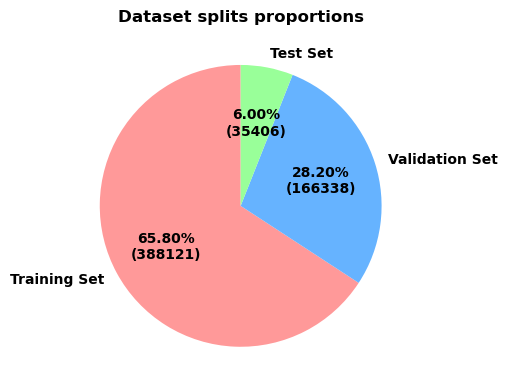

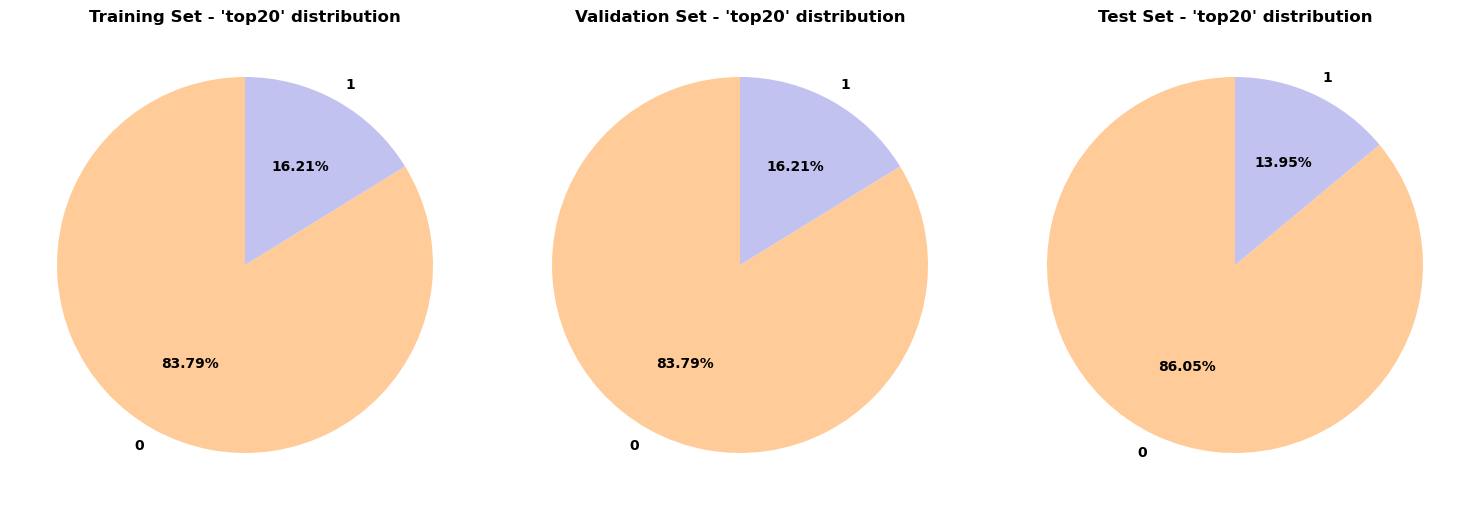

In [50]:
#Set sizes
train_size = train_set.shape[0]
validation_size = validation_set.shape[0]
test_size = test_set.shape[0]
original_size = train_size + validation_size + test_size

# Pie plot for the set sizes
set_sizes = [train_size, validation_size, test_size]
set_labels = ["Training Set", "Validation Set", "Test Set"]
set_colors = ["#ff9999", "#66b3ff", "#99ff99"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(
    set_sizes,
    labels=set_labels,
    autopct=lambda p: f'{p:.2f}%\n({p*original_size/100:.0f})',
    startangle=90,
    colors=set_colors,
    textprops={'fontweight': 'bold'}
)
plt.title("Dataset splits proportions", fontweight='bold')

# Pie plot for the class distribution in the 3 partitions 
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

distributions = [training_top20_counts, validation_top20_counts, test_top20_counts]
titles = ["Training Set", "Validation Set", "Test Set"]
colors = [["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"]]

for ax, data, title, color in zip(axes, distributions, titles, colors):
    ax.pie(
        data,
        labels=data.index,
        autopct='%1.2f%%',
        startangle=90,
        colors=color,
        textprops={'fontweight': 'bold'}
    )
    ax.set_title(f"{title} - 'top20' distribution", fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

We immediately notice the fact that we are in an "unbalanced" context, with a minority '1' class.

In [51]:
train_set.isna().sum()

race_year                0
points                   0
length                   0
climb_total              0
profile                  0
startlist_quality        0
BMI                      0
birth_year               0
median position_2021     0
AVG position_2021        0
# cyclist races_2021     0
std_dev position_2021    0
geo area_num             0
dtype: int64

In [52]:
validation_set.isna().sum()

race_year                0
points                   0
length                   0
climb_total              0
profile                  0
startlist_quality        0
BMI                      0
birth_year               0
median position_2021     0
AVG position_2021        0
# cyclist races_2021     0
std_dev position_2021    0
geo area_num             0
dtype: int64

In [53]:
test_set.isna().sum()

race_year                   0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
BMI                         0
birth_year                  0
median position_2021     3615
AVG position_2021        3615
# cyclist races_2021     3615
std_dev position_2021    3615
geo area_num                0
dtype: int64

Only the test set have some records with NaNs, for the reasons described above. Notice that there are 3615 with NaN statistics over 35406 total test set rows (about 10%).

Let's save the dataset and the data partitions because some classifiers require some pre-processing steps. In the saved version the 'geo area' column has been ecoded with a number. We decide to keep the geo area because it has a reasonable amount of values so, if we need to use the one hot encoding, we do not generate too many artificial columns. 

If required, the mapping 'geo area' --> 'geo area_num' has been printed in the coding function.

In [54]:
# class_preprocessed_dataset has been saved before
class_preprocessed_train_set=train_set.copy()
class_preprocessed_validation_set=validation_set.copy()
class_preprocessed_test_set=test_set.copy()

For the usage of the grid search exploiting the **Cross Validation** technique, we need to use both training and validation data. For this reason we keep also a combined version of them.

In [55]:
print(validation_set.shape)
print(train_set.shape)
train_combined=np.vstack((validation_set, train_set)) #vertical stacking
print(train_combined.shape)

(166338, 13)
(388121, 13)
(554459, 13)


In [56]:
print(validation_label.shape)
print(train_label.shape)
train_label_combined=np.concatenate((validation_label, train_label)) #vertical stacking
print(train_label_combined.shape)

(166338,)
(388121,)
(554459,)


# Models testing

## Evaluation functions

In [57]:
def plot_PR_ROC_AUC(classifier, input_data, predicted_labels):
    # Check if the model supports predict_proba
    if not hasattr(classifier, "predict_proba"):
        print("This model does not support predict_proba().")
        return None

    # Get the probabilities of the positive classes
    y_prob = classifier.predict_proba(input_data)[:, 1]
    
    precision, recall, _ = precision_recall_curve(predicted_labels, y_prob)
    auc_pr = auc(recall, precision)  # AUC of the precision-recall curve
    print(f"AUC-PR of the classifier: {auc_pr:.4f}")

    fpr, tpr, _ = roc_curve(predicted_labels, y_prob)
    roc_auc = auc(fpr, tpr)  # AUC of the ROC curve
    print(f"AUC-ROC of the classifier: {roc_auc:.4f}")

    # Set up the figure with two subplots (side by side)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Precision-Recall Curve
    ax[0].plot(recall, precision, color='b', linewidth=2, label=f'AUC-PR = {auc_pr:.4f}')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title("Precision-Recall Curve", fontweight='bold')
    ax[0].legend(loc="best")
    ax[0].grid(alpha=0.3)

    # ROC Curve
    ax[1].plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    # Diagonal line that represents the random classifier
    ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('ROC Curve', fontweight='bold')
    ax[1].legend(loc='best')
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

In [58]:
#Custom function to print the classification report con training/valid
def print_report(train_label, train_predictions, validation_label, valid_predictions):
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print('VALIDATION SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

In [129]:
def plot_confusion_matrix(classifier, prior_labels, predicted_labels):
    cm = confusion_matrix(prior_labels, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
    disp.plot()
    plt.title("Confusion Matrix", fontweight='bold')
    plt.show()
    plt.close()

| `Metric`    | `Formula`                                                                                   | `Description`                                                        |
|---------------|-----------------------------------------------------------------------------------------------|------------------------------------------------------------------------|
| **Precision** or **TPR**| $ \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$ |Proportion of true positive predictions out of all the positive predictions (TP + FP).|
| **Recall**    | $ \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} $                                   | Proportion of true positive predictions out of all the actual positives (TP + FN).|
| **F1 Score**  | $ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $ | Harmonic mean of Precision and Recall, balancing both metrics.|
| **FPR**  | $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$ | Proportion of the "real" negatives classified as positive.|
| **Accuracy**  | $\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{FP} + \text{TN} + \text{FN}}$ | Proportion of the correct predictions. Not the best metric to consider in inbalanced settings.|

The **AUC-ROC** is a measure of the separability of the two classes by the defined classifier. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1.

The **AUC-Precision/Recall** is a useful measure of success of prediction when the classes are very imbalanced. The PR AUC quantifies how well a model can distinguish between classes, considering both its ability to not mark a negative sample as positive (Precision) and its ability to find all the positive samples (Recall). PR AUC is often used when dealing with imbalanced datasets.


## Decision Tree

**Parameters**: <br>
- `max_depth`: Controls the maximum depth of the tree; If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. If too high the DT can better describe the training data but there is the risk of overfitting.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. 
- `max_features`: The number of features to consider when looking for the best split.
- `criterion`: The function to measure the quality of a split. 
- `split`: The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.

In [60]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(train_set, train_label)

In [61]:
#predict using the decision tree
#the predict function returns the actual predicted labels: we need them for the evaluation phase
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [62]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)
# 'Macro' AVG refers to the simple average between the metrics on the 2 classes without particular weights
# 'Weighted' AVG weights the measures considering the number of instances of the two classes

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.98      0.92    325195
       top20       0.72      0.28      0.41     62926

    accuracy                           0.87    388121
   macro avg       0.80      0.63      0.67    388121
weighted avg       0.85      0.87      0.84    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.87      0.98      0.92    139370
       top20       0.69      0.27      0.39     26968

    accuracy                           0.86    166338
   macro avg       0.78      0.62      0.65    166338
weighted avg       0.84      0.86      0.83    166338



In this first attempt, we immediately notice that the model has very poor *recall* and *F1-score* for the 'top 20' class (1), which is the underrepresented class. This may be due to the fact that we are in a highly unbalanced setting, since in the training and validation set 83% of the records have a label 'top-20'==0. **So in this case is crucial to assign the proper weights to the classes or using other pre-processing strategies like the Undesampling/Oversampling**.

AUC-PR of the classifier: 0.5321
AUC-ROC of the classifier: 0.8076


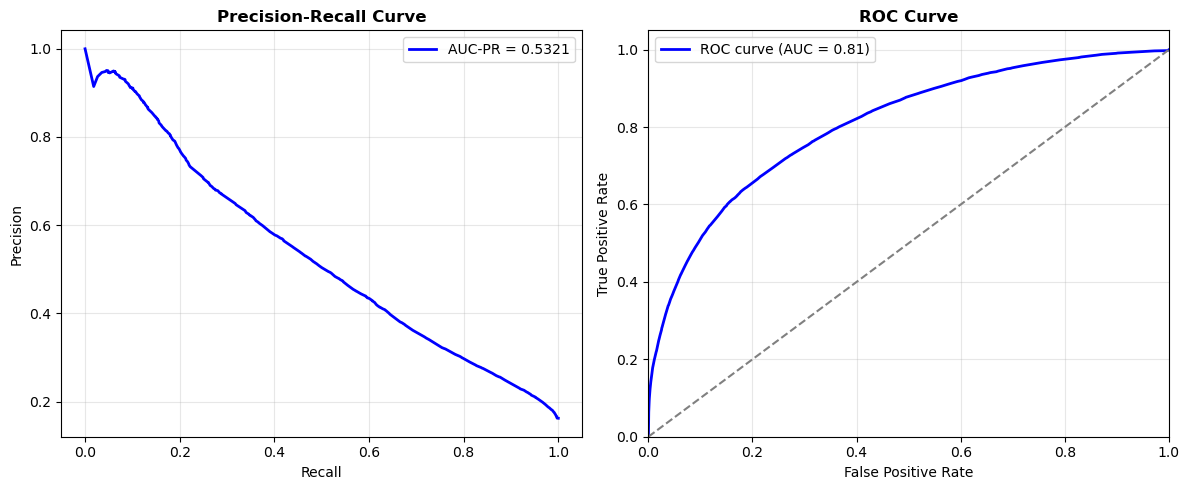

In [63]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

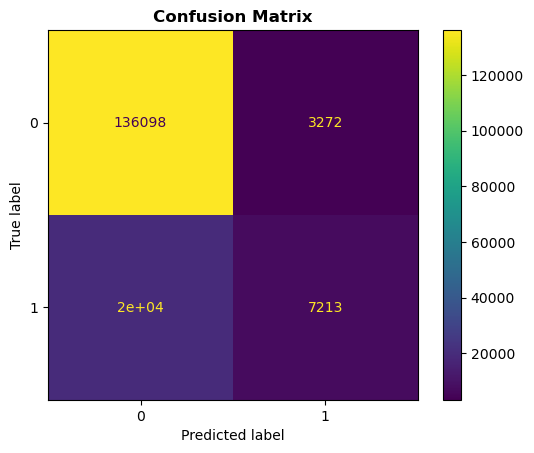

In [64]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

As shown in the statistics, this initial configuration of the model is not able to distinguish well the data with a '1' label, since this is the minority class. In fact we have a vary low recall for this class. We need to properly manage these inbalanced classes.

### Weights adjustment

Try a Randomized GridSearch to find the best parameters of the model, including the weights given to each class. Notice that in an context where the two classes are not balanced, the *accuracy* is not the best measure to maximize in our search. It's better to use the *ROC_AUC*, which is the **area under the curve** of the *Receiver Operating Characteristics*, that takes into account the *True Positive Rate (TPR)* and the *False Positive Rate (FPR)* giving a more balanced measure of the ability to separate the two classes. Another reason to support this metric, is the fact that in this context <ins>we are interested in finding the top-20 scorers (labelled with the positive class)</ins> among all the participants.

In [65]:
def GridSearchCVExecution(hyperparameters, classifier, training_data, training_label, scoring_, cross_validation=None, max_iterations=None):
    #Parameters:
    # - hyperparameters: dictionary of the parameters of the classifier to be tested
    # - classifier: classifier to optimize.
    # - training_data / training_labels: data used to train the model with the associated labels
    # - cross_validation (int, optional): number of fold to be used in case of a cross validation
    # - scoring: metric to be optimized during the search
    # - max_iterations (int, optional): maximum number of tests for a RandomizedSearchCV.

    if max_iterations is not None:
        search = RandomizedSearchCV(
            estimator=classifier,
            param_distributions=hyperparameters,
            n_iter=max_iterations,
            n_jobs=-1,
            scoring=scoring_,
            cv=cross_validation,
            random_state=RANDOM_STATE
        )
    else:
        search = GridSearchCV(
            estimator=classifier,
            param_grid=hyperparameters,
            n_jobs=-1,
            scoring=scoring_,
            cv=cross_validation
        )

    search.fit(training_data, training_label)
    # Returns the results of the searching process
    return search


In [66]:
def save_grid_search_results(grid_result, filename="grid_search_results.txt"):
    # The function saves the grid search results in a textual file
    # The tests are sorted according to the score maximixed in the grid search (area under the curve)
    
    # Result extraction
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    
    # Generate the tuples and sort by score (desc)
    results = sorted(zip(means, stds, params), key=lambda x: x[0], reverse=True)

    with open(filename, "w") as f:
        f.write("Best configuration: %f using %s\n" % (grid_result.best_score_, grid_result.best_params_))
        f.write("Mean and std of this setting: %f - %f\n\n" % (
            grid_result.cv_results_['mean_test_score'][0], 
            grid_result.cv_results_['std_test_score'][0]
        ))
        f.write("All configurations sorted by score:\n")
        for mean, stdev, param in zip(
            grid_result.cv_results_['mean_test_score'], 
            grid_result.cv_results_['std_test_score'], 
            grid_result.cv_results_['params']
        ):
            f.write("Mean: %f, Std: %f with: %r\n" % (mean, stdev, param))

In [67]:
def retrieve_grid_search_results(filename):
    with open(filename, "r") as file:
        for i in range(3):  # The first 3 rows contain the best result and the mean/std dev of the setting
            line = file.readline().strip()
            print(line)

#### ROC AUC Grid Search

In [68]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_combined, training_label=train_label_combined, classifier=classifier, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

In [69]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_ROC_AUC_13_12.txt")

In [89]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_ROC_AUC_13_12.txt")

Best configuration: 0.813585 using {'class_weight': {0: 1, 1: 20}, 'criterion': 'gini', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 47, 'min_samples_split': 45}
Mean and std of this setting: 0.791066 - 0.002992



In [71]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:20} ,criterion='gini', splitter='best', max_depth=50, min_samples_split=45, min_samples_leaf=47, max_features='log2')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [72]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.99      0.44      0.60    325195
       top20       0.25      0.97      0.40     62926

    accuracy                           0.52    388121
   macro avg       0.62      0.70      0.50    388121
weighted avg       0.87      0.52      0.57    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.96      0.43      0.59    139370
       top20       0.24      0.92      0.38     26968

    accuracy                           0.51    166338
   macro avg       0.60      0.67      0.48    166338
weighted avg       0.85      0.51      0.56    166338



AUC-PR of the classifier: 0.5272
AUC-ROC of the classifier: 0.8107


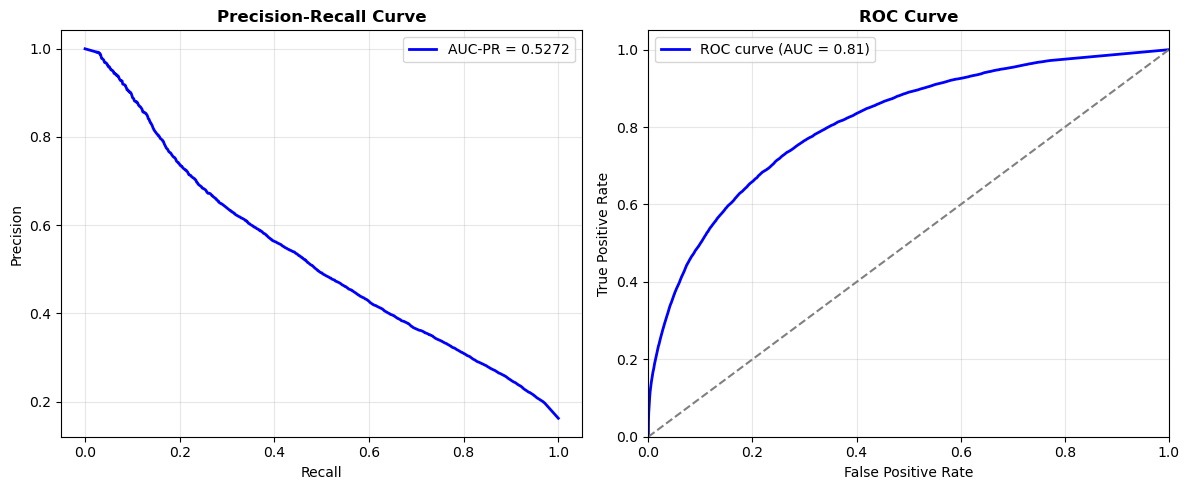

In [73]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

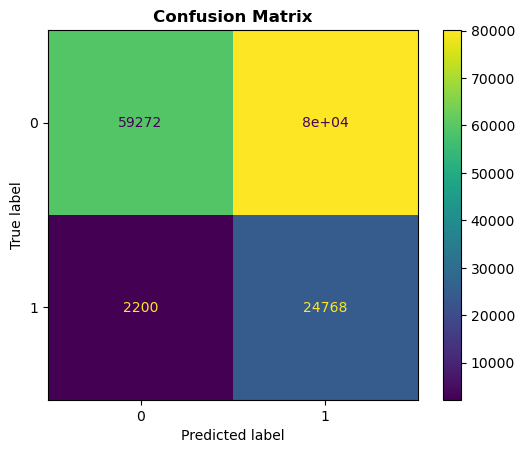

In [74]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

As we can see from the statistics, by assigning a weight ratio of 1:20, we have obtained more or less the same ROC AUC value as before, but we have worsened the recall for class 0 and the precision for class 1. Therefore, we have defined a classifier that is more biased towards class 1, as can be seen in the confusion matrix, where there are many 0 objects classified as 1.

#### Precision/Recall AUC Grid Search

In [75]:
#grid_search = GridSearchCVExecution(param_dist, training_data=train_combined, training_label=train_label_combined, classifier=classifier, scoring_='average_precision', cross_validation=cv, max_iterations=n_iter_search)
grid_search = None

In [76]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_PR_AUC_13_12.txt")

In [77]:
retrieve_grid_search_results("GridSearchResults/randomizedGridSearch_DT_PR_AUC_13_12.txt")

Best configuration: 0.539927 using {'class_weight': {0: 1, 1: 20}, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 44, 'min_samples_split': 26}
Mean and std of this setting: 0.516006 - 0.005461



In [78]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:20} ,criterion='gini', splitter='best', max_depth=30, min_samples_split=26, min_samples_leaf=44, max_features='sqrt')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [79]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.99      0.44      0.61    325195
       top20       0.25      0.97      0.40     62926

    accuracy                           0.53    388121
   macro avg       0.62      0.71      0.51    388121
weighted avg       0.87      0.53      0.58    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.96      0.43      0.59    139370
       top20       0.24      0.91      0.38     26968

    accuracy                           0.51    166338
   macro avg       0.60      0.67      0.48    166338
weighted avg       0.84      0.51      0.56    166338



AUC-PR of the classifier: 0.5241
AUC-ROC of the classifier: 0.8086


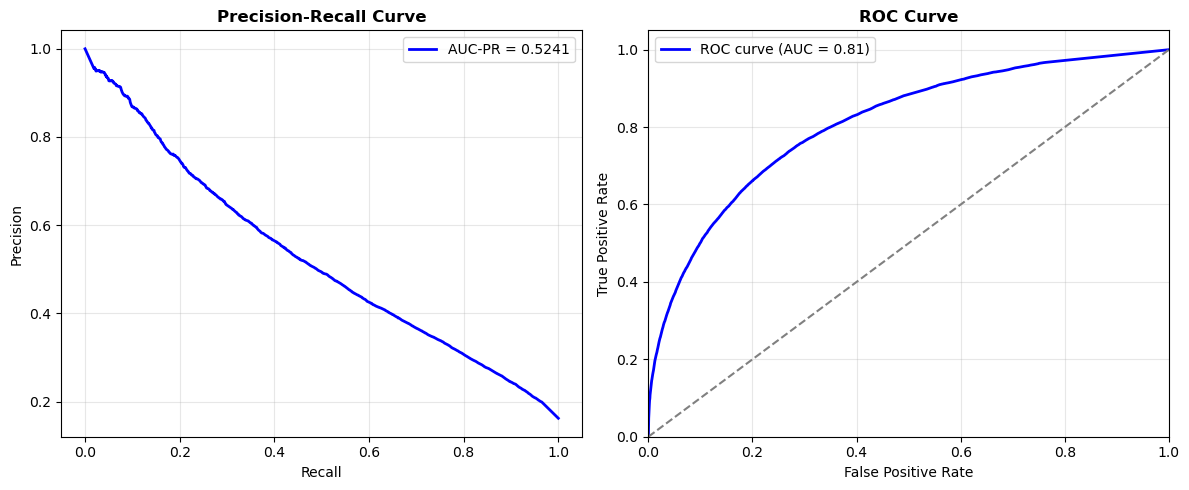

In [80]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

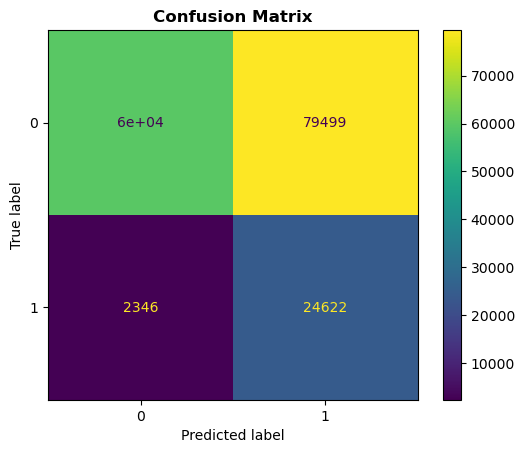

In [81]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

Basically, since we have generated a DT quite similar to the previous one, the considerarions are actually the same.

#### F1 Weighted Grid Search

In [82]:
grid_search = GridSearchCVExecution(param_dist, training_data=train_combined, training_label=train_label_combined, classifier=classifier, scoring_='f1_weighted', cross_validation=cv, max_iterations=n_iter_search)
#grid_search = None

In [83]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_F1W_14_12.txt")

In [84]:
retrieve_grid_search_results("GridSearchResults/randomizedGridSearch_DT_F1W_14_12.txt")

Best configuration: 0.784966 using {'class_weight': {0: 1, 1: 10}, 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2}
Mean and std of this setting: 0.682309 - 0.001334



In [85]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:10} ,criterion='entropy', splitter='best', max_depth=50, min_samples_split=2, min_samples_leaf=3, max_features='log2')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [86]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       1.00      0.84      0.92    325195
       top20       0.55      1.00      0.71     62926

    accuracy                           0.87    388121
   macro avg       0.78      0.92      0.81    388121
weighted avg       0.93      0.87      0.88    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.78      0.85    139370
       top20       0.37      0.66      0.47     26968

    accuracy                           0.76    166338
   macro avg       0.64      0.72      0.66    166338
weighted avg       0.83      0.76      0.78    166338



AUC-PR of the classifier: 0.5057
AUC-ROC of the classifier: 0.7466


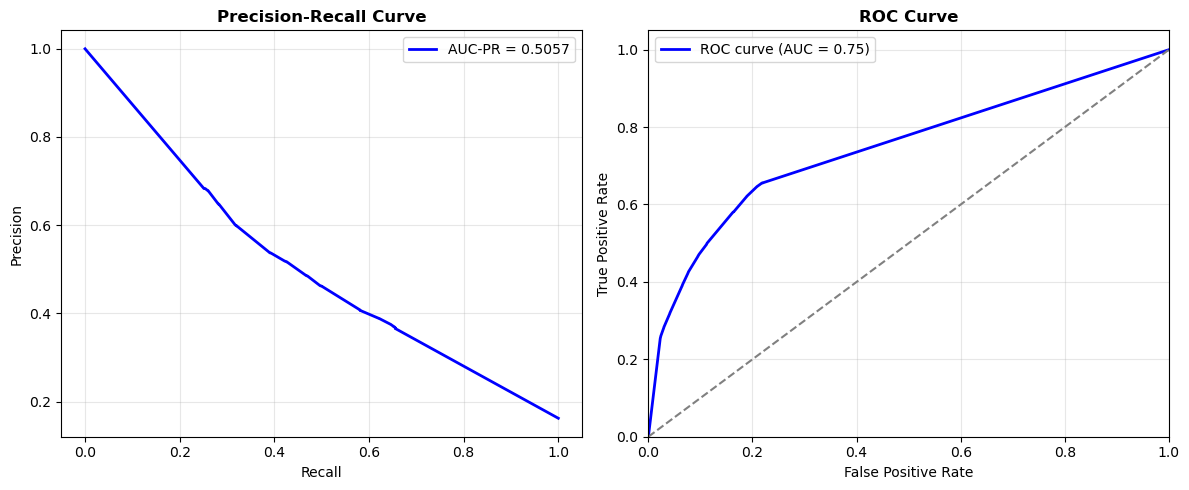

In [87]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

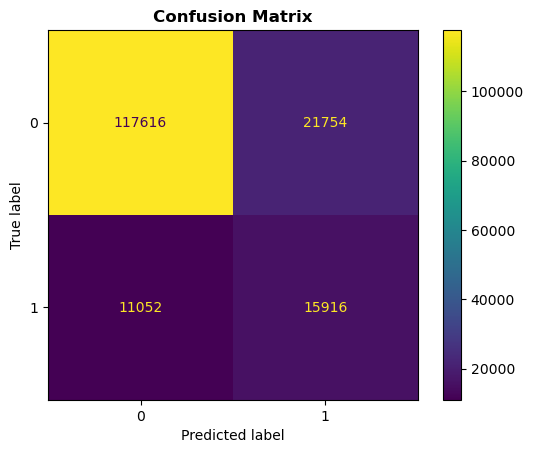

In [130]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

The statistics showed that probably we have definined a model which is overfitting our data with a 1 precision for the 0 class.

### Undersampling strategy
Under-sample the majority class by randomly picking samples with or without replacement. Notice that this strategy can exclude relevant data from the majority class.

In [164]:
from imblearn.under_sampling import RandomUnderSampler

In [165]:
# sampling_strategy --> if float, it is the desired ratio of the # of samples in the minority class over the # of 
#   samples in the majority class after resampling.
rand_undersampler=RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

#Let's balance the classes with the proportion 0:60% - 1:40% (vs 87%-13% in the initial setting)
#40/60=0.67

In [166]:
# The undersampling is done only on the training data! The validation set is used to assess the model
# learnt using this corrective strategy for an imbalanced setting
train_set_us, train_label_us = rand_undersampler.fit_resample(train_set, train_label)

In [167]:
print(train_label_us.value_counts(normalize=True))
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_us.shape[0]}")

top20
0    0.598801
1    0.401199
Name: proportion, dtype: float64
Initial training set size 388121. After undersampling 156845


Actually this strategy has halved the data available for training the model.

In [168]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(train_set_us, train_label_us)
train_pred_dt = dt.predict(train_set_us)
valid_pred_dt = dt.predict(validation_set)

In [169]:
print_report(train_label_us, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.76      0.87      0.81     93919
       top20       0.76      0.59      0.67     62926

    accuracy                           0.76    156845
   macro avg       0.76      0.73      0.74    156845
weighted avg       0.76      0.76      0.75    156845

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.85      0.88    139370
       top20       0.44      0.58      0.50     26968

    accuracy                           0.81    166338
   macro avg       0.67      0.72      0.69    166338
weighted avg       0.84      0.81      0.82    166338



In [170]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_us[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: race_year, KS statistic: 0.0381, P-value: 0.0000
Column: points, KS statistic: 0.0139, P-value: 0.0000
Column: length, KS statistic: 0.0079, P-value: 0.0000
Column: climb_total, KS statistic: 0.0053, P-value: 0.0041
Column: profile, KS statistic: 0.0061, P-value: 0.0005
Column: startlist_quality, KS statistic: 0.0305, P-value: 0.0000
Column: BMI, KS statistic: 0.0120, P-value: 0.0000
Column: birth_year, KS statistic: 0.0375, P-value: 0.0000
Column: median position_2021, KS statistic: 0.0764, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0767, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0175, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0187, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0047, P-value: 0.0157


In all columns, the p-value is extremely low (practically 0.0000), suggesting that all column distributions are significantly different between train_set and train_set_os (the oversampled dataset).

#### F1 Macro Grid Search
Since we have already performed a class balancing using the undersampling, let's try a grid search using the 'f1 macro' as the measure to maximise. For the same reason we do not try to change the class weights.

In [115]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_us, training_label=train_label_us, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [116]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_US_F1M_14_12.txt")

In [ ]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_US_F1M_14_12.txt")

Best configuration: 0.719442 using {'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 43}
Mean and std of this setting: 0.718758 - 0.002250



In [120]:
# define a decision tree using the parameters that have maximised the F1 Macro (in an oversampling setting)
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=15, min_samples_split=43, min_samples_leaf=6, max_features='log2')
dt = dt.fit(train_set_us, train_label_us)
train_pred_dt = dt.predict(train_set_us)
valid_pred_dt = dt.predict(validation_set)
print_report(train_label_us, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.78      0.87      0.82     93919
       top20       0.77      0.63      0.69     62926

    accuracy                           0.77    156845
   macro avg       0.77      0.75      0.76    156845
weighted avg       0.77      0.77      0.77    156845

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.84      0.88    139370
       top20       0.42      0.59      0.49     26968

    accuracy                           0.80    166338
   macro avg       0.67      0.72      0.69    166338
weighted avg       0.83      0.80      0.82    166338



AUC-PR of the classifier: 0.5057
AUC-ROC of the classifier: 0.8027


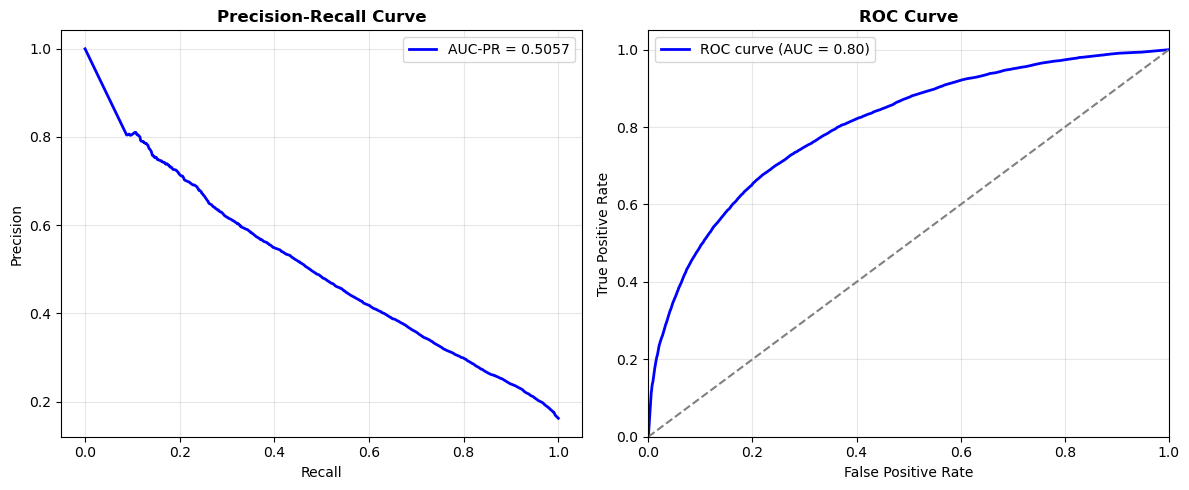

In [121]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

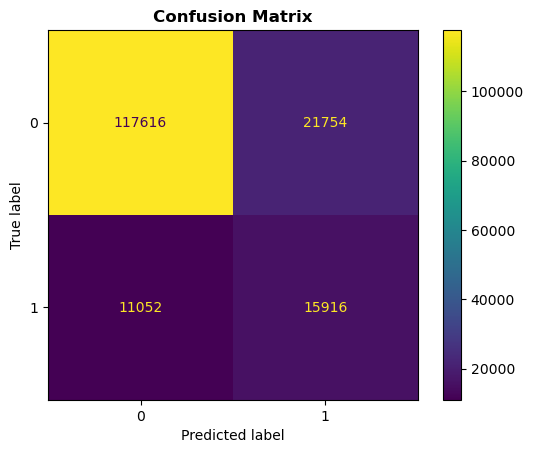

In [131]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

Even by adopting this strategy the under-represented class continues to have some limitations.

### Oversampling strategy TODO
Over-sample the minority class by picking samples at random with replacement.
- provare Random
- provere SMOTE

#### Random Oversampler

In [134]:
from imblearn.over_sampling import RandomOverSampler

In [154]:
# sampling_strategy --> if float, it is the desired ratio of the # of samples in the minority class over the # of 
#   samples in the majority class after resampling.
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

#Let's balance the classes with the proportion 0:60% - 1:40% (vs 87%-13% in the initial setting)
#40/60=0.67

In [155]:
# The oversampling is done only on the training data! The validation set is used to assess the model
# learnt using this corrective strategy for an imbalanced setting
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [156]:
print(train_label_os.value_counts(normalize=True))
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_os.shape[0]}")

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64
Initial training set size 388121. After undersampling 543075


In this case the number of training samples is increased, since some instances of the minority class have been duplicated.

In [157]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(train_set_os, train_label_os)
train_pred_dt = dt.predict(train_set_os)
valid_pred_dt = dt.predict(validation_set)

In [158]:
print_report(train_label_os, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.77      0.86      0.81    325195
       top20       0.74      0.61      0.67    217880

    accuracy                           0.76    543075
   macro avg       0.75      0.73      0.74    543075
weighted avg       0.76      0.76      0.75    543075

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.85      0.88    139370
       top20       0.44      0.59      0.50     26968

    accuracy                           0.81    166338
   macro avg       0.68      0.72      0.69    166338
weighted avg       0.84      0.81      0.82    166338



In [162]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_os[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: race_year, KS statistic: 0.0388, P-value: 0.0000
Column: points, KS statistic: 0.0144, P-value: 0.0000
Column: length, KS statistic: 0.0071, P-value: 0.0000
Column: climb_total, KS statistic: 0.0044, P-value: 0.0003
Column: profile, KS statistic: 0.0056, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0296, P-value: 0.0000
Column: BMI, KS statistic: 0.0116, P-value: 0.0000
Column: birth_year, KS statistic: 0.0374, P-value: 0.0000
Column: median position_2021, KS statistic: 0.0768, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0769, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0164, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0184, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0046, P-value: 0.0001


In all columns, the p-value is extremely low (practically 0.0000), suggesting that all column distributions are significantly different between train_set and train_set_os (the oversampled dataset).

In [ ]:
#to find the best set of parameter setting, we can run a grid search
# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_os, training_label=train_label_os, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [144]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_OS_F1M_15_12.txt")

In [145]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_OS_F1M_15_12.txt")

Best configuration: 0.812494 using {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26}
Mean and std of this setting: 0.747280 - 0.002754



In [151]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50, min_samples_split=26, min_samples_leaf=1, max_features='sqrt')
dt = dt.fit(train_set_os, train_label_os)
train_pred_dt = dt.predict(train_set_os)
valid_pred_dt = dt.predict(validation_set)
print_report(train_label_os, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.90      0.90    325195
       top20       0.85      0.87      0.86    217880

    accuracy                           0.89    543075
   macro avg       0.88      0.88      0.88    543075
weighted avg       0.89      0.89      0.89    543075

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.84      0.87    139370
       top20       0.41      0.56      0.47     26968

    accuracy                           0.80    166338
   macro avg       0.66      0.70      0.67    166338
weighted avg       0.83      0.80      0.81    166338



AUC-PR of the classifier: 0.4890
AUC-ROC of the classifier: 0.7573


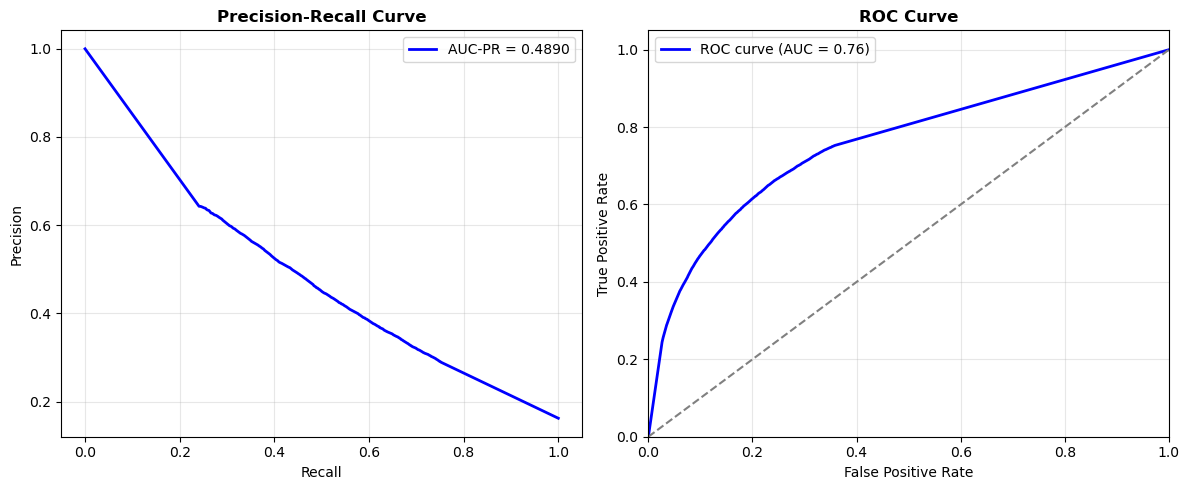

In [152]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

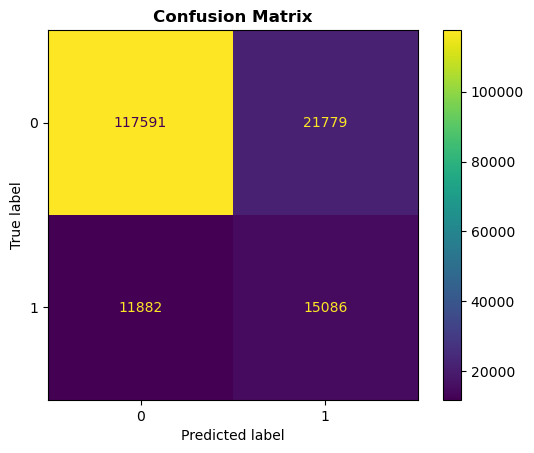

In [153]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

#### SMOTE: Synthetic Minority Oversampling Technique
The Synthetic Minority Over-Sampling Technique (SMOTE) is a used to handle class imbalance in datasets. SMOTE handles this issue by generating samples of minority classes to make the class distribution balanced. The algorith m uses an approach based on the K-NN classifier. So we need to perform the proper preprocessing.

In [171]:
from imblearn.over_sampling import SMOTE

smote_oversampler = SMOTE(sampling_strategy=0.67, random_state=RANDOM_STATE)

In [172]:
train_set_smote, train_label_smote = smote_oversampler.fit_resample(train_set, train_label)

In [173]:
print(train_label_smote.value_counts(normalize=True))
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_smote.shape[0]}")

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64
Initial training set size 388121. After undersampling 543075


In [174]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_smote[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: race_year, KS statistic: 0.0382, P-value: 0.0000
Column: points, KS statistic: 0.0179, P-value: 0.0000
Column: length, KS statistic: 0.0067, P-value: 0.0000
Column: climb_total, KS statistic: 0.0043, P-value: 0.0005
Column: profile, KS statistic: 0.0060, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0297, P-value: 0.0000
Column: BMI, KS statistic: 0.0182, P-value: 0.0000
Column: birth_year, KS statistic: 0.0410, P-value: 0.0000
Column: median position_2021, KS statistic: 0.0827, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0842, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0173, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0126, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0548, P-value: 0.0000


**TODO** Le colonne con differenze significative sono median_position, AVG position_2021, geo area_num. Levare le colonne ordinali, vedere se utile normalizzazione, separare già ad inizio notebook i vari preprocessing dei dati.

# Spazzatura | Altri classificatori

We can observe that the mean of the configaration tested is quite similar to the best found and also the standard deviation is quite low.

In [75]:
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=20, max_features='log2', min_samples_split=42, min_samples_leaf=39, class_weight='balanced')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [76]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.95      0.76      0.84    325195
       top20       0.39      0.79      0.52     62926

    accuracy                           0.76    388121
   macro avg       0.67      0.77      0.68    388121
weighted avg       0.86      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.93      0.74      0.83    139370
       top20       0.36      0.73      0.48     26968

    accuracy                           0.74    166338
   macro avg       0.65      0.74      0.65    166338
weighted avg       0.84      0.74      0.77    166338



**Considerazioni AUC-ROC**
L'area under the curve (AUC), in particolare l'AUC-ROC, è un parametro utile per valutare modelli anche in caso di dati sbilanciati, ma va utilizzato con cautela. <br>
Pro dell'AUC-ROC in caso di dati sbilanciati <br>
- Indipendenza dal Threshold: L'AUC-ROC considera la performance del modello su tutti i possibili threshold, quindi non è influenzato dalla scelta di un particolare cut-off.
- Capacità di distinguere le classi: Una AUC vicina a 1 indica che il modello è molto bravo a distinguere tra la classe positiva e quella negativa. 
- Limitazioni dell'AUC-ROC con dati sbilanciati

Ignora la Distribuzione delle Classi: L'AUC-ROC valuta solo quanto bene il modello separa le classi, ma non tiene conto del fatto che una classe sia molto meno rappresentata. Questo può mascherare problemi pratici:
Un modello con ottima separazione tra classi (alto AUC) potrebbe comunque performare male nel rilevare la classe minoritaria (ad esempio, avere un recall molto basso per la classe positiva). Nei dati sbilanciati, il ROC curve può essere dominato dalla performance sulla classe maggioritaria, rendendo il risultato meno rappresentativo della classe di interesse. 
Usare il ROC-AUC è utile per confrontare diversi modelli senza concentrarti su una specifica classe. Non è ideale come metrica principale se il focus è sul miglioramento della performance per la classe minoritaria.
<br>

Alternative in caso di dati sbilanciati
**AUC-PR (Precision-Recall Curve)**
La curva Precision-Recall (PR) si concentra sulla classe positiva e tiene conto della precision (esattezza delle predizioni positive) e del recall (capacità di catturare i positivi). È più rappresentativa per dataset sbilanciati, poiché mette in evidenza la performance sulla classe positiva. Evita di essere influenzata dalla classe maggioritaria. L'F1-score è una media armonica tra precision e recall, che dà uguale importanza a entrambi.
Se hai bisogno di dare maggiore peso al recall (ad esempio, nel rilevamento di frodi o malattie), puoi usare l'Fβ-score, dove β>1 favorisce il recall. Si può monitorare direttamente la capacità del modello di catturare la classe minoritaria. L'AUC-ROC è utile per valutare la capacità generale di separare le classi, ma nei casi di dati sbilanciati, l'AUC-PR è generalmente un parametro più rappresentativo della performance del modello, specialmente se l'interesse principale è ottimizzare la classe minoritaria. In combinazione con metriche come il recall o l'F1-score, fornisce un quadro più completo della qualità del modello.

## Naive Bayes Classifiers

In [77]:
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_class_weight

# Determining the prior probabilities 
# class_weight='balanced' --> Weights assigned in a way which is inversely proportional to the frequecies,
# # in this way less represented classes will receive an higher weights. 
class_prior = compute_class_weight(class_weight='balanced', classes=np.unique(train_label), y=train_label)
class_prior = class_prior / np.sum(class_prior) #normalization of the probabilities to sum 1
gnb = GaussianNB(priors=class_prior)
gnb.fit(train_set, train_label)

#predictions
train_pred_gnb = gnb.predict(train_set)
valid_pred_gnb = gnb.predict(validation_set)

In [78]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_gnb)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.95      0.76      0.84    325195
       top20       0.39      0.79      0.52     62926

    accuracy                           0.76    388121
   macro avg       0.67      0.77      0.68    388121
weighted avg       0.86      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.39      0.56    139370
       top20       0.22      0.87      0.35     26968

    accuracy                           0.47    166338
   macro avg       0.58      0.63      0.45    166338
weighted avg       0.82      0.47      0.52    166338



For the validation set, the precision of the minority class and the overall accuracy is very low.

In [79]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB(class_prior=class_prior)
bnb.fit(train_set, train_label)

#predictions
train_pred_bnb = bnb.predict(train_set)
valid_pred_bnb = bnb.predict(validation_set)

In [80]:
print_report(train_label=train_label, train_predictions=train_pred_bnb, validation_label=validation_label, valid_predictions=valid_pred_bnb)

TRAINING SET RESULTS


c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   not top20       0.00      0.00      0.00    325195
       top20       0.16      1.00      0.28     62926

    accuracy                           0.16    388121
   macro avg       0.08      0.50      0.14    388121
weighted avg       0.03      0.16      0.05    388121

--------------------
VALIDATION SET RESULTS


c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   not top20       0.00      0.00      0.00    139370
       top20       0.16      1.00      0.28     26968

    accuracy                           0.16    166338
   macro avg       0.08      0.50      0.14    166338
weighted avg       0.03      0.16      0.05    166338



c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**TODO** Probabilmente l'errore è dovuto alla mancanza di campioni per una determinata classe. Indagare.

## Random Forest

The Random Forest is an instance of the Bagging family of *Ensamble Methods*. <br>
- Sampling with replacement
- Build classifier on each bootstrap sample
- Each sample has probability (1 – 1/n)n of being selected

In [82]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features=3,
                             max_depth=4, 
                             min_samples_split=2,
                             min_samples_leaf=8,
                             bootstrap=True) 
rf = rf.fit(train_set, train_label)

In [83]:
train_pred_rf = rf.predict(train_set)
valid_pred_rf = rf.predict(validation_set)

In [84]:
print_report(train_label=train_label, train_predictions=train_pred_rf, validation_label=validation_label, valid_predictions=valid_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.85      1.00      0.92    325195
       top20       0.84      0.08      0.14     62926

    accuracy                           0.85    388121
   macro avg       0.84      0.54      0.53    388121
weighted avg       0.85      0.85      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.85      1.00      0.92    139370
       top20       0.84      0.08      0.15     26968

    accuracy                           0.85    166338
   macro avg       0.85      0.54      0.53    166338
weighted avg       0.85      0.85      0.79    166338



We notice that in this first attempt we have a very bad recall on the minority class. We need to try different weights. So let's set up a RandomizedGridSearch to explore different parameters.

In [ ]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}],
              "n_estimators": [15, 20, 30]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50
#define the model
classifier = RandomForestClassifier(bootstrap=True)
#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

In [ ]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_RF_12_12.txt")

In [ ]:
#Print the best configuration
# 80 min 21sec for this search
# print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# print('Mean and std of this setting ', grid_search.cv_results_['mean_test_score'][0], 
#        grid_search.cv_results_['std_test_score'][0])

Best: 0.853006 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting  0.8511198312757873 0.000929031675275066


In [94]:
retrieve_grid_search_results("randomizedGridSearch_RF_12_12.txt")

Best configuration: 0.853006 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting: 0.851120 - 0.000929



**TODO** Min_sample_leaf=1, è un problema??

In [95]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=50, 
                             min_samples_split=26,
                             min_samples_leaf=1,
                             bootstrap=True) 
rf = rf.fit(train_set, train_label)

In [96]:
train_pred_rf = rf.predict(train_set)
valid_pred_rf = rf.predict(validation_set)

In [97]:
print_report(train_label=train_label, train_predictions=train_pred_rf, validation_label=validation_label, valid_predictions=valid_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.99      0.94    325195
       top20       0.89      0.46      0.60     62926

    accuracy                           0.90    388121
   macro avg       0.90      0.72      0.77    388121
weighted avg       0.90      0.90      0.89    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.98      0.93    139370
       top20       0.76      0.35      0.48     26968

    accuracy                           0.88    166338
   macro avg       0.82      0.66      0.70    166338
weighted avg       0.86      0.88      0.86    166338



**Considerazioni AUC-ROC**
L'area under the curve (AUC), in particolare l'AUC-ROC, è un parametro utile per valutare modelli anche in caso di dati sbilanciati, ma va utilizzato con cautela. <br>
Pro dell'AUC-ROC in caso di dati sbilanciati <br>
- Indipendenza dal Threshold: L'AUC-ROC considera la performance del modello su tutti i possibili threshold, quindi non è influenzato dalla scelta di un particolare cut-off.
- Capacità di distinguere le classi: Una AUC vicina a 1 indica che il modello è molto bravo a distinguere tra la classe positiva e quella negativa. 
- Limitazioni dell'AUC-ROC con dati sbilanciati

Ignora la Distribuzione delle Classi: L'AUC-ROC valuta solo quanto bene il modello separa le classi, ma non tiene conto del fatto che una classe sia molto meno rappresentata. Questo può mascherare problemi pratici:
Un modello con ottima separazione tra classi (alto AUC) potrebbe comunque performare male nel rilevare la classe minoritaria (ad esempio, avere un recall molto basso per la classe positiva). Nei dati sbilanciati, il ROC curve può essere dominato dalla performance sulla classe maggioritaria, rendendo il risultato meno rappresentativo della classe di interesse. 
Usare il ROC-AUC è utile per confrontare diversi modelli senza concentrarti su una specifica classe. Non è ideale come metrica principale se il focus è sul miglioramento della performance per la classe minoritaria.
<br>

Alternative in caso di dati sbilanciati
**AUC-PR (Precision-Recall Curve)**
La curva Precision-Recall (PR) si concentra sulla classe positiva e tiene conto della precision (esattezza delle predizioni positive) e del recall (capacità di catturare i positivi). È più rappresentativa per dataset sbilanciati, poiché mette in evidenza la performance sulla classe positiva. Evita di essere influenzata dalla classe maggioritaria. L'F1-score è una media armonica tra precision e recall, che dà uguale importanza a entrambi.
Se hai bisogno di dare maggiore peso al recall (ad esempio, nel rilevamento di frodi o malattie), puoi usare l'Fβ-score, dove β>1 favorisce il recall. Si può monitorare direttamente la capacità del modello di catturare la classe minoritaria. L'AUC-ROC è utile per valutare la capacità generale di separare le classi, ma nei casi di dati sbilanciati, l'AUC-PR è generalmente un parametro più rappresentativo della performance del modello, specialmente se l'interesse principale è ottimizzare la classe minoritaria. In combinazione con metriche come il recall o l'F1-score, fornisce un quadro più completo della qualità del modello.

## AdaBoost

The [AdaBoostClassifier](https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) (Adaptive Boosting) is an *ensemble* learning algorithm that <ins>combines multiple weak learners (often shallow decision trees) to create a strong learner</ins>. Its core idea is to iteratively adjust the weights of samples, emphasizing those that are harder to classify, and aggregate predictions from all learners to make final decisions.

In [105]:
# Estimator --> The base estimator from which the boosted ensemble is built. If None, then the base estimator is DecisionTreeClassifier
#   initialized with max_depth=1. In this case we properly set the weights of the classes.
# n_estimators: int, default=50 --> The maximum number of estimators at which boosting is terminated. 
# learning_rate: float, default=1.0 --> Weight applied to each classifier at each boosting iteration. A 
#   higher learning rate increases the contribution of each classifier.
# random_state: Controls the random seed given at each estimator at each boosting iteration.

abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5, class_weight='balanced'), random_state=RANDOM_STATE)
abc.fit(train_set, train_label)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=5),
                   random_state=42)

In [106]:
train_pred_abc=abc.predict(train_set)
valid_pred_abc=abc.predict(validation_set)

In [107]:
print_report(train_label=train_label, train_predictions=train_pred_abc, validation_label=validation_label, valid_predictions=valid_pred_abc)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.77      0.84    325195
       top20       0.38      0.75      0.51     62926

    accuracy                           0.76    388121
   macro avg       0.66      0.76      0.68    388121
weighted avg       0.85      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.76      0.84    139370
       top20       0.37      0.73      0.49     26968

    accuracy                           0.76    166338
   macro avg       0.65      0.75      0.67    166338
weighted avg       0.84      0.76      0.78    166338



In [ ]:
from scipy.stats import uniform, randint

dtc=DecisionTreeClassifier(class_weight='balanced')
abc=AdaBoostClassifier(estimator=dtc, random_state=RANDOM_STATE)

param_dist = {
    'n_estimators': [30, 50, 75, 100],
    'learning_rate': uniform(0.01, 1),
    'estimator__max_depth': [1, 3, 5]
}

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the grid search
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=abc, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

KeyboardInterrupt: 

In [ ]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_ABC_12_12.txt")

## SVM Support Vector Machine

Versione di SVM Lineare per grandi [datasets](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

Altro classificatore con gradiente discentende [qui](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier)

In [ ]:
weights = {0:1.0, 1:100.0}

# C: Regularization parameter >0. The strength of the regularization is inversely proportional to C.
# kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}, specifies the kernel type to be used in the algorithm.
# gamma is the kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’
svm = SVC(gamma='scale', class_weight=weights)
svm.fit(train_set, train_label)

In [ ]:
svm = SVC(gamma='scale', C=0.5)
svm.fit(train_set, train_label)

## K-NN

In the classifiers that exploit the notion of distance, it's important to apply a preliminary normalization step so that we reduce the bias given by the range of the different attributes. In this case we use a standardization (z-score normalization).

Let's retrieve the original dataset that we have to standardize and let's apply the one hot encoding to the geo area column.

In [81]:
dataset=class_preprocessed_dataset.copy()
dataset

,race_year,points,length,climb_total,profile,startlist_quality,BMI,birth_year,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num,top20
0,1970,225,240000,2611,2.0,372,22.057578,1946.0,4.0,13.0,37.0,18.685480,7,1
1,1970,225,240000,2611,2.0,372,18.646937,1944.0,6.0,10.0,10.0,8.141116,7,1
2,1970,225,240000,2611,2.0,372,22.840000,1947.0,8.0,16.0,67.0,18.234961,7,1
3,1970,225,240000,2611,2.0,372,21.748939,1946.0,4.0,7.0,38.0,7.836705,7,1
4,1970,225,240000,2611,2.0,372,22.727257,1947.0,19.0,20.0,7.0,9.860938,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,2022,350,266900,4167,2.0,1052,20.760000,1999.0,NaN,NaN,NaN,NaN,7,0
589861,2022,350,266900,4167,2.0,1052,19.660000,1999.0,NaN,NaN,NaN,NaN,4,0
589862,2022,350,266900,4167,2.0,1052,19.810000,1997.0,44.0,57.0,114.0,40.958639,7,0
589863,2022,350,266900,4167,2.0,1052,20.600000,1999.0,80.0,68.0,16.0,37.999507,4,0


In [82]:
# Remove the profile column which is an ordinal
# Remove the birth_year and the 'race_year' since an euclidean distance on these feature is not meaningful
# We use the geo area_num after a one-hot-encoding transformation
train_set.drop(['profile', 'birth_year', 'race_year'], axis=1, inplace=True)
validation_set.drop(['profile', 'birth_year', 'race_year'], axis=1, inplace=True)
print(train_set.columns)
print(validation_set.columns)

Index(['points', 'length', 'climb_total', 'startlist_quality', 'BMI',
       'median position_2021', 'AVG position_2021', '# cyclist races_2021',
       'std_dev position_2021', 'geo area_num'],
      dtype='object')
Index(['points', 'length', 'climb_total', 'startlist_quality', 'BMI',
       'median position_2021', 'AVG position_2021', '# cyclist races_2021',
       'std_dev position_2021', 'geo area_num'],
      dtype='object')


In [83]:
print(train_set.shape[0])
print(validation_set.shape[0])

388121
166338


In [84]:
scaler = StandardScaler()
columns_to_be_scaled=['points', 'length', 'climb_total', 'startlist_quality', 'BMI', 'median position_2021', 'AVG position_2021', '# cyclist races_2021', 'std_dev position_2021']

save_geo_area=train_set.pop('geo area_num')
print(save_geo_area.shape[0])
std_train_set = pd.DataFrame(scaler. fit_transform(train_set), columns=columns_to_be_scaled)
std_train_set = pd.concat([std_train_set.reset_index(drop=True), save_geo_area.reset_index(drop=True)], axis=1)

save_geo_area=validation_set.pop('geo area_num')
print(save_geo_area.shape[0])
std_validation_set = pd.DataFrame(scaler. fit_transform(validation_set), columns=columns_to_be_scaled)
std_validation_set = pd.concat([std_validation_set.reset_index(drop=True), save_geo_area.reset_index(drop=True)], axis=1)

388121
166338


In [85]:
std_train_set = pd.get_dummies(std_train_set, columns = ['geo area_num'], prefix_sep='_')
std_validation_set = pd.get_dummies(std_validation_set, columns = ['geo area_num'], prefix_sep='_')

In [86]:
std_train_set.head()


,points,length,climb_total,startlist_quality,BMI,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num_0,geo area_num_1,geo area_num_2,geo area_num_3,geo area_num_4,geo area_num_5,geo area_num_6,geo area_num_7
0,-0.728096,-2.369577,-1.385926,-1.563562,-0.508091,-0.365177,-0.319392,1.667509,-0.104368,False,False,False,False,False,False,False,True
1,0.192462,-0.038884,-0.483802,1.582779,-0.174131,-0.365177,-0.144150,-0.437693,-0.385515,False,False,False,False,False,False,False,True
2,0.192462,-0.069672,-0.689936,1.700964,-0.748852,0.216548,0.293954,0.667276,-1.150534,False,False,False,False,False,False,False,True
3,0.192462,0.615373,-0.841305,2.000365,1.290245,-0.365177,-0.538444,-0.788560,1.028693,False,False,False,False,False,False,True,False
4,-0.728096,-2.460403,-1.732780,0.133046,1.091807,-0.467834,-0.494634,1.117643,-0.473784,False,False,False,False,False,False,True,False


In [87]:
std_validation_set.head()

,points,length,climb_total,startlist_quality,BMI,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num_0,geo area_num_1,geo area_num_2,geo area_num_3,geo area_num_4,geo area_num_5,geo area_num_6,geo area_num_7
0,0.189752,-0.549709,1.303735,0.658326,-2.259760,1.246764,1.086640,-1.241344,-0.608856,False,False,False,False,False,False,False,True
1,-0.727065,-1.240442,-0.411298,-1.507999,-0.393986,-0.501028,-0.537543,1.525876,-0.460451,False,False,False,False,False,False,True,False
2,-0.176975,0.226981,0.003777,-0.221825,1.826099,1.041142,0.867156,-0.680563,0.347224,False,False,False,False,False,False,False,True
3,-0.727065,-0.043172,-0.564100,0.102992,0.299469,0.390004,0.208703,-0.570503,-0.032807,False,False,False,False,False,False,True,False
4,-0.176975,1.000601,-0.469073,-0.499492,0.603892,0.150111,0.077013,-0.638635,-0.576285,False,False,False,False,True,False,False,False


The K-NN classifier has not the possibility to define a weight for each class. So we try the classifier with different configurations and see how it performs. We expect that if we increase too much K, the classifier will always answer with the majority class (0).

In [88]:
# hyperparameters = {
#     'n_neighbors': [2, 3, 5, 7, 9, 10],  # Try different K values
#     'metric': ['euclidean', 'manhattan', 'minkowski'],  # Try different metrics
#     'weights': ['uniform', 'distance'],  # Try to weight the "voting" consider the distance of the neighbors
# }

# knn = KNeighborsClassifier()

# grid_search = GridSearchCVExecution(
#     hyperparameters=hyperparameters,
#     classifier=knn,
#     training_data=std_train_set,
#     training_label=train_label,
#     scoring_='roc_auc',
#     cross_validation=5,
#     max_iterations=None
# )

In [89]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_KNN_10_12.txt")

In [90]:
#Print the best configuration
# 24 min 36sec for this search
# print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# print('Mean and std of this setting ', grid_search.cv_results_['mean_test_score'][0], 
#       grid_search.cv_results_['std_test_score'][0])

In [91]:
#['auto', 'ball_tree', 'kd_tree', 'brute']
knn = KNeighborsClassifier(n_neighbors=2, algorithm='auto', metric='minkowski').fit(std_train_set, train_label)

In [ ]:
valid_pred_knn = knn.predict(std_train_set)

: 

: 

In [ ]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_dt)